In [2]:
import h5py
import psana
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import  rotate
from scipy.interpolate import interp1d
from scipy.optimize import curve_fit,minimize
import multiprocessing
import os
from functools import partial
import time
import sys
import argparse
from datetime import datetime
import tempfile
import XSpect.XSpect_Analysis
import XSpect.XSpect_Controller
import XSpect.XSpect_Visualization
import XSpect.XSpect_Diagnostics as dt
import XSpect.XSpect_PostProcessing

Run 90 imported


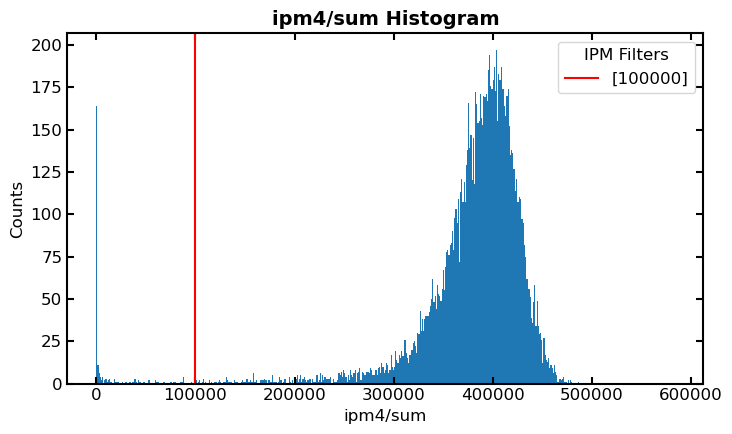

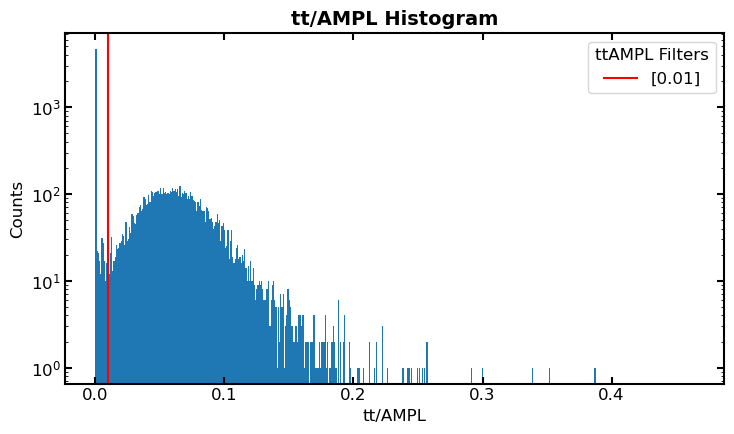

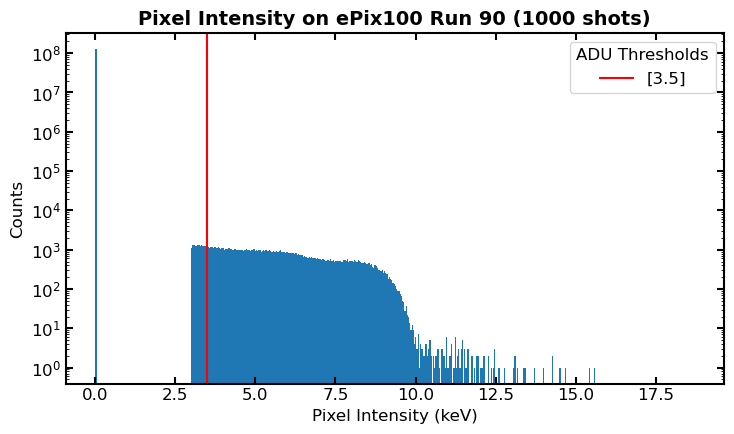

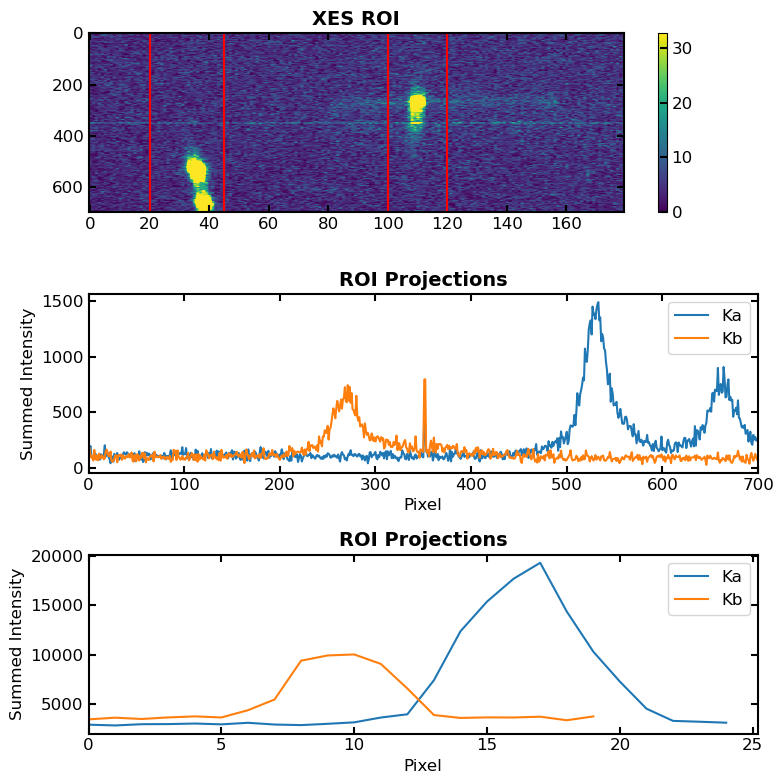

Rotating image by -1.2 degree(s)


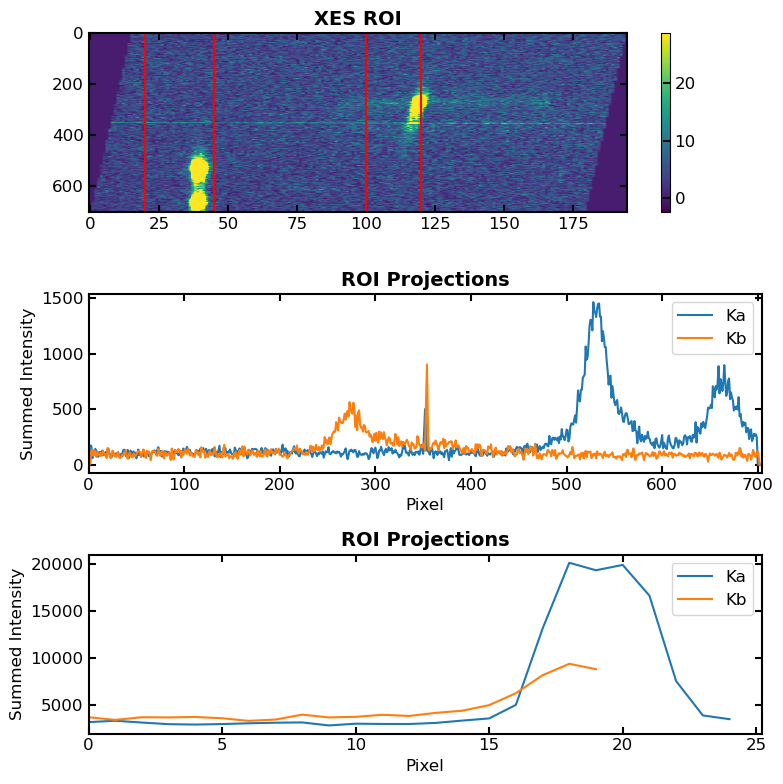

Rotating image by 0.6 degree(s)


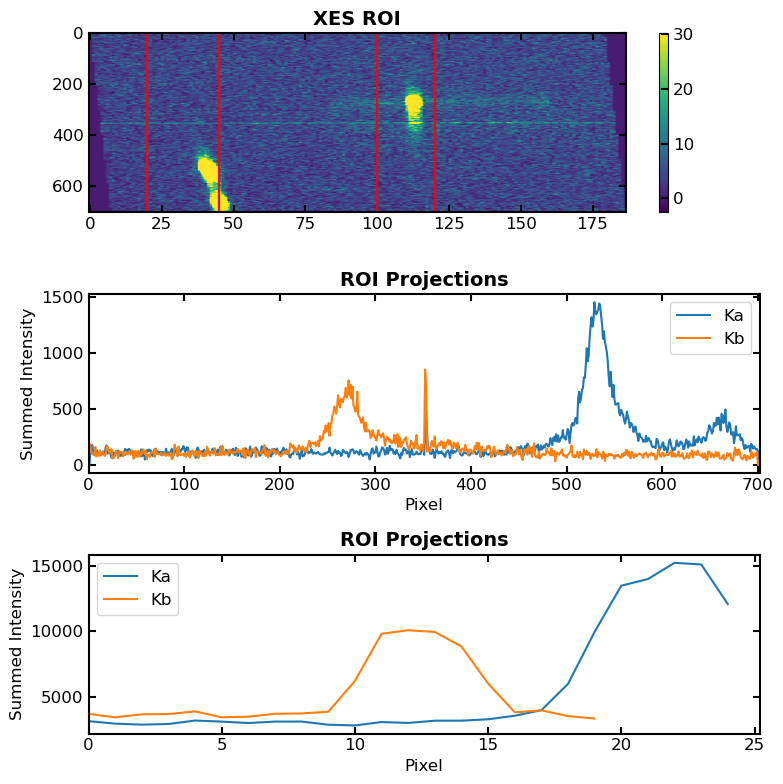

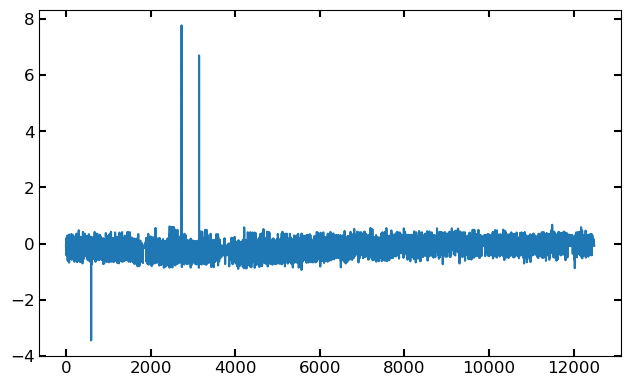

In [3]:
run = 90
exp = 'xcs101577926'

### For example run = 0
# keys=['epics/dccm_E','tt/ttCorr','epics/lxt_ttc', 'enc/lasDelay' , 'ipm4/sum','tt/AMPL','epix_2/ROI_0_area'] 
# names=['energy','time_tool_correction','lxt_ttc'  ,'encoder','ipm', 'time_tool_ampl','epix']

### For current runs

keys=['epics/dccm_E','tt/ttCorr','epics/lxt', 'enc/lasDelay' , 'ipm4/sum','tt/AMPL','epix_2/ROI_area'] 
names=['energy','time_tool_correction','lxt_ttc'  ,'encoder','ipm', 'time_tool_ampl','epix']

d = dt.diagnostics(run, exp, keys, names)

ipm_thres = [100000]

d.ipm_histogram(ipm_thres)

tt_thres = [0.01]

d.ttAMPL_histogram(tt_thres)

# d.droplet_histogram()

nshots = 1000

adu_thres = [3.5]
d.adu_histogram(nshots, adu_thres)

kb_roi = [100, 120]
ka_roi = [20, 45]

d.xes_ROI(nshots, ka_limits = ka_roi, kb_limits = kb_roi, angle = 0)
d.xes_ROI(nshots, ka_limits = ka_roi, kb_limits = kb_roi, angle = -1.2)
d.xes_ROI(nshots, ka_limits = ka_roi, kb_limits = kb_roi, angle = 0.6)

delay = d.h5[d.datadict['time_tool_correction']][:] + d.h5[d.datadict['lxt_ttc']][:] + d.h5[d.datadict['encoder']][:]

plt.plot(delay)

In [3]:
start = time.time()

xes_experiment = XSpect.XSpect_Analysis.spectroscopy_experiment(hutch='xcs',experiment_id='xcs101577926',lcls_run=26)
xes1=XSpect.XSpect_Controller.ScanAnalysis_1D_XES()
keys=['epics/dccm_E','tt/ttCorr','epics/lxt', 'enc/lasDelay' , 'ipm4/sum', 'tt/AMPL'] 
names=['energy','time_tool_correction','lxt_ttc'  ,'encoder','ipm', 'time_tool_ampl']

#Here we define the epix detector keys separately as they are imported separately to avoid OOM
xes1.key_epix=['epix_2/ROI_area']
xes1.friendly_name_epix=['epix']

# xes1.key_epix=['epix_2/ROI_0_area']
# xes1.friendly_name_epix=['epix']

##
xes1.set_key_aliases(keys,names)

xes1.use_droplets = False
xes1.scattering = True
xes1.rois         = [ka_roi, kb_roi]
xes1.combine_rois = False
xes1.adu_cutoff   = 3.5
xes1.angle        = [-1.2, 0.6]

xtal1 = {'crystal' : 'LiNbO3',
         'h'       : 2,
         'k'       : 3,
         'l'       : 4,
         'radius'  : 250,
         'detector_distance' : 44.35}

xtal2 = {'crystal' : 'Ge',
         'h'       : 6,
         'k'       : 2,
         'l'       : 0,
         'radius'  : 250,
         'detector_distance' : 44.85}

xes1.crystal_dict = [xtal1, xtal2]

# xes.lxt_key=None

xes1.transpose=False
xes1.add_filter('xray','ipm',100.0E3)
xes1.add_filter('simultaneous','ipm',100.0E3)
xes1.add_filter('simultaneous','time_tool_ampl',0.01)

xes1.run_parser(['90'])

In [4]:
start=time.time()

f = xes1.primary_analysis(xes_experiment, run = 90, verbose=True)

end=time.time()
print('Analysis completed: %.02f s' % (end - start))

Obtained shot properties
HDF5 import of keys completed. Time: 0.00 seconds
HDF5 import of keys completed. Time: 2.12 seconds
Applied ROIs to detector: epix with ROI: 20, 45
Applied ROIs to detector: epix with ROI: 100, 120
Shots (8858) combined for detector ipm on filters: simultaneous and laser into ipm_simultaneous_laser
Shots (3543) separated for detector ipm on filters: xray and laser into ipm_xray_not_laser
Shots (8858) combined for detector scan on filters: simultaneous and laser into scan_simultaneous_laser
Shots (3543) separated for detector scan on filters: xray and laser into scan_xray_not_laser
Shots (8858) combined for detector scanvar_indices on filters: simultaneous and laser into scanvar_indices_simultaneous_laser
Shots (3543) separated for detector scanvar_indices on filters: xray and laser into scanvar_indices_xray_not_laser
Key: epix_ROI_1 has been adu filtered by threshold: 3.500000
Rotated epix_ROI_1 by -1.200000 degrees. Time: 26.41
Shots (8858) combined for detect

In [24]:
def diff_viz(experiment, time_points, en_rebin_by = 0, time_rebin_by = 0, xlimits = [], roi_names = [], data2plotlabel = '_summed_difference_normalized'):
    roi_list = getattr(experiment, 'roi_list')
    fig, ax = plt.subplots(figsize = (6, 6), nrows = 2, ncols = len(roi_list))

    for indx, roi in enumerate(roi_list):
        data2plot = getattr(experiment, roi + data2plotlabel)
        try:
            std2plot = getattr(experiment, roi + data2plotlabel + '_std')
        except:
            std2plot = None
        energy = getattr(getattr(experiment, 'analyzed_runs')[0], roi + '_energy')
        time = getattr(experiment, 'time_bins')

        if roi_names == []:
            name = roi
        elif len(roi_names) == len(roi_list):
            name = roi_names[indx]

        if en_rebin_by > 1:
            if std2plot is not None:
                energy, data2plot, std2plot = rebinner(energy, data2plot, en_rebin_by, axis = 1, std2rebin = std2plot)
            else:
                energy, data2plot = rebinner(energy, data2plot, en_rebin_by, axis = 1, std2rebin = std2plot)
            print('Energy axis rebinned by %i pixel steps' % en_rebin_by)
        if time_rebin_by > 1:
            if std2plot is not None:
                time, data2plot, std2plot = rebinner(time, data2plot, time_rebin_by, axis = 0, std2rebin = std2plot)
            else:
                time, data2plot = rebinner(time, data2plot, time_rebin_by, axis = 0, std2rebin = std2plot)
            print('Time axis rebinned by %i pixel steps' % en_rebin_by)
            print('Time axis now in %.2f ps steps' % np.diff(time)[0])
        
        vmax = np.nanmax(np.abs(data2plot))
        vmin = -vmax
        contlevels = np.linspace(vmin*0.75, vmax*0.75, 20)

        if xlimits == []:
            xlimits_use = [min(energy), max(energy)]
        else:
            xlimits_use = xlimits[indx]

        if len(roi_list) == 1:
            plt_indx0 = (0,)
            plt_indx1 = (1,)
        elif len(roi_list) > 1:
            plt_indx0 = (0,indx)
            plt_indx1 = (1,indx)
            
        ax[plt_indx0].contourf(energy, time, data2plot, contlevels, cmap = 'RdBu')
        ax[plt_indx0].set_xlim(xlimits_use)
        ax[plt_indx0].set_title(name)
        if indx == 0:
            ax[plt_indx0].set_ylabel('Time (ps)')
        elif indx > 0:
            ax[plt_indx0].set_yticklabels([])


        offset = 0
        ytick_vals = []
        ytick_labels = []
        for i, tp in enumerate(time_points):
            if i == 0:
                if std2plot is not None:
                    offsetval = np.nanmax(np.abs(data2plot[indx,:] + std2plot[indx,:]))*2
                else:
                    offsetval = np.nanmax(np.abs(data2plot[indx,:]))*2
            time_indx = np.argmin(np.abs(time - tp))
            ax[plt_indx1].plot(energy, data2plot[time_indx,:] - offset, label = ('%.1f ps' % tp))
            if std2plot is not None:
                ax[plt_indx1].fill_between(energy, data2plot[time_indx,:] - offset - std2plot[time_indx,:], data2plot[time_indx,:] - offset + std2plot[time_indx,:], alpha = 0.4)
            ytick_vals.append(0 - offset)
            ytick_labels.append('%.1f ps' % time[time_indx])
            offset += offsetval

        ax[plt_indx1].set_xlim(xlimits_use)
        ax[plt_indx1].set_xlabel('Energy (eV)')
        if indx == 0 or indx == None:
            ax[plt_indx1].set_ylabel('Difference')
            ax[plt_indx1].set_yticks(ytick_vals)
            ax[plt_indx1].set_yticklabels(ytick_labels)
        elif indx > 0:
            ax[plt_indx1].set_yticklabels([])

def rebinner(axis2rebin, data2rebin, rebin_by, axis = 0, std2rebin = None):
    rebin_length = np.round(axis2rebin.shape[0]/rebin_by)
    rebin_mod = axis2rebin.shape[0]%rebin_by

    if rebin_mod > 0:
        rebinshape = int(rebin_length)+1
    else:
        rebinshape = int(rebin_length)
    axis_rebinned = np.zeros(rebinshape)
    if axis == 0:
        data_rebinned = np.zeros((rebinshape, data2rebin.shape[1]))
        for indx_rebin, indx_orig in enumerate(np.arange(0, axis2rebin.shape[0], rebin_by)):
            axis_rebinned[indx_rebin] = np.nanmean(axis2rebin[indx_orig:(indx_orig + rebin_by)])
            data_rebinned[indx_rebin, :] = np.nanmean(data2rebin[indx_orig:(indx_orig + rebin_by), :], axis = axis)
    elif axis == 1:
        data_rebinned = np.zeros((data2rebin.shape[0], rebinshape))
        for indx_rebin, indx_orig in enumerate(np.arange(0, axis2rebin.shape[0], rebin_by)):
            axis_rebinned[indx_rebin] = np.nanmean(axis2rebin[indx_orig:(indx_orig + rebin_by)])
            data_rebinned[:, indx_rebin] = np.nanmean(data2rebin[:, indx_orig:(indx_orig + rebin_by)], axis = axis)

    if std2rebin is not None:
        if axis == 0:
            std_rebinned = np.zeros((rebinshape, std2rebin.shape[1]))
            for indx_rebin, indx_orig in enumerate(np.arange(0, axis2rebin.shape[0], rebin_by)):
                for stdindx in np.arange(indx_orig,(indx_orig + rebin_by)):
                    if stdindx < std2rebin.shape[0]:
                        std_rebinned[indx_rebin, :] =+ std2rebin[stdindx, :]**2
            std_rebinned = np.sqrt(std_rebinned)
        elif axis == 1:
            std_rebinned = np.zeros((std2rebin.shape[0], rebinshape))
            for indx_rebin, indx_orig in enumerate(np.arange(0, axis2rebin.shape[0], rebin_by)):
                for stdindx in np.arange(indx_orig,(indx_orig + rebin_by)):
                    if stdindx < std2rebin.shape[1]:
                        std_rebinned[:, indx_rebin] =+ std2rebin[:, stdindx]**2
            std_rebinned = np.sqrt(std_rebinned)/rebin_by

        return axis_rebinned, data_rebinned, std_rebinned
    else:
        return axis_rebinned, data_rebinned

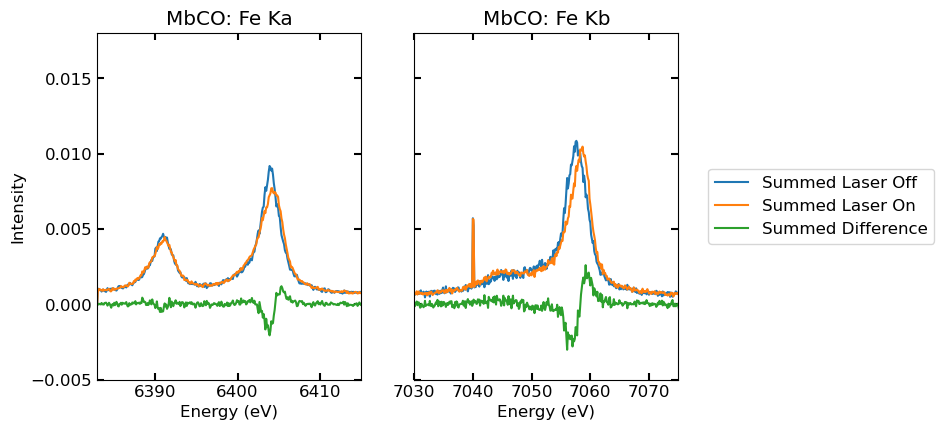

In [25]:
fig, ax = plt.subplots(1,2)

ylimits = [-0.005, 0.018]

t0guess = np.argmin(np.abs(xes1.time_bins - 1))

ax[0].plot(xes1.analyzed_runs[0].epix_ROI_1_energy, np.nanmean(xes1.epix_ROI_1_summed_laser_off_normalized, axis = 0))
ax[0].plot(xes1.analyzed_runs[0].epix_ROI_1_energy, np.nanmean(xes1.epix_ROI_1_summed_laser_on_normalized[t0guess:,:], axis = 0))
ax[0].plot(xes1.analyzed_runs[0].epix_ROI_1_energy, np.nanmean(xes1.epix_ROI_1_summed_difference_normalized[t0guess:,:], axis = 0))
ax[0].set_xlim([min(xes1.analyzed_runs[0].epix_ROI_1_energy), 6415])
ax[0].set_ylim(ylimits)
ax[0].set_title('MbCO: Fe Ka')
ax[0].set_xlabel('Energy (eV)')
ax[0].set_ylabel('Intensity')

ax[1].plot(xes1.analyzed_runs[0].epix_ROI_2_energy, np.nanmean(xes1.epix_ROI_2_summed_laser_off_normalized, axis = 0))
ax[1].plot(xes1.analyzed_runs[0].epix_ROI_2_energy, np.nanmean(xes1.epix_ROI_2_summed_laser_on_normalized[t0guess:,:], axis = 0))
ax[1].plot(xes1.analyzed_runs[0].epix_ROI_2_energy, np.nanmean(xes1.epix_ROI_2_summed_difference_normalized[t0guess:,:], axis = 0))
ax[1].set_xlim([7030, 7075])
ax[1].set_ylim(ylimits)
ax[1].set_title('MbCO: Fe Kb')
ax[1].set_yticklabels([])
ax[1].set_xlabel('Energy (eV)')

ax[1].legend(['Summed Laser Off', 'Summed Laser On', 'Summed Difference'], loc = 'right', bbox_to_anchor = (2,0.5))

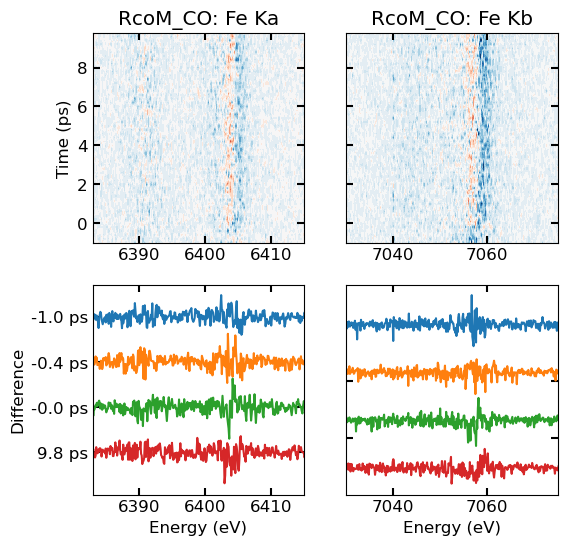

In [27]:
roi_names = ['RcoM_CO: Fe Ka', 'RcoM_CO: Fe Kb']
roi_xlimits = [ [min(xes1.analyzed_runs[0].epix_ROI_1_energy), 6415], [7030, 7075] ]

diff_viz(xes1, time_points = [-1, -0.5, 0, 10], xlimits = roi_xlimits, en_rebin_by = 1, time_rebin_by = 1, roi_names = roi_names)

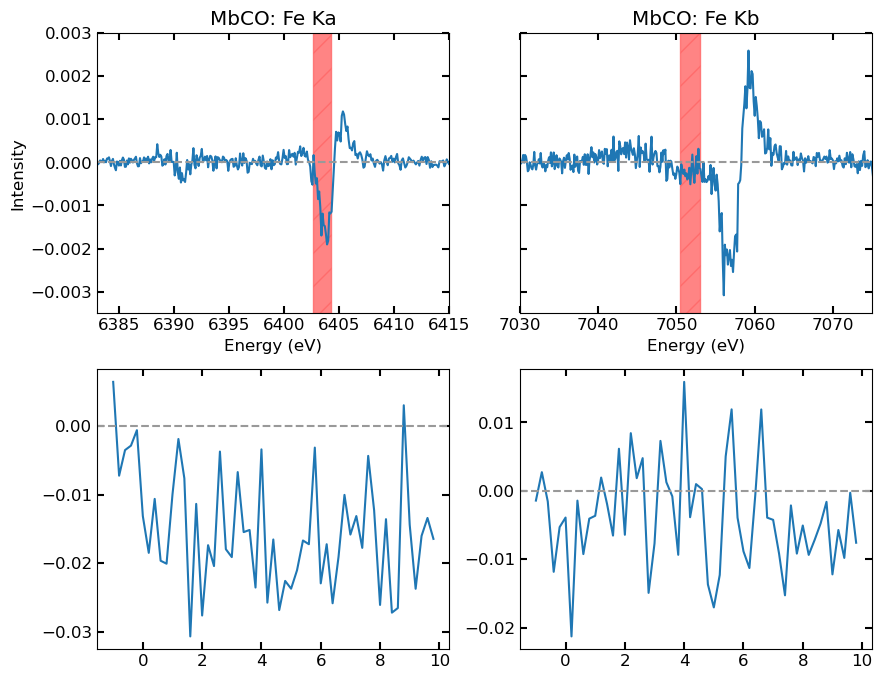

In [28]:
fig, ax = plt.subplots(figsize = (10,8), ncols = 2, nrows = 2)

ylimits = [-0.0035, 0.003]
ka_ll, ka_ul = 6402.6, 6404.2
kb_ll, kb_ul = 7050.5, 7053

t0guess = np.argmin(np.abs(xes1.time_bins - 0))

ka_ll_indx, ka_ul_indx = np.argmin(np.abs(xes1.analyzed_runs[0].epix_ROI_1_energy - ka_ll)), np.argmin(np.abs(xes1.analyzed_runs[0].epix_ROI_1_energy - ka_ul))
kb_ll_indx, kb_ul_indx = np.argmin(np.abs(xes1.analyzed_runs[0].epix_ROI_2_energy - kb_ll)), np.argmin(np.abs(xes1.analyzed_runs[0].epix_ROI_2_energy - kb_ul))

ka_ttrace = np.nansum(xes1.epix_ROI_1_summed_difference_normalized[:,ka_ll_indx:ka_ul_indx], axis = 1)
kb_ttrace = np.nansum(xes1.epix_ROI_2_summed_difference_normalized[:,kb_ll_indx:kb_ul_indx], axis = 1)

ax[0,0].plot(xes1.analyzed_runs[0].epix_ROI_1_energy, np.nanmean(xes1.epix_ROI_1_summed_difference_normalized[t0guess:,:], axis = 0))
ax[0,0].axhline(0, color = np.array([150,150,150])/250, linestyle = '--')
ax[0,0].fill_between([ka_ll, ka_ul], ylimits[0], ylimits[1], color = np.array([250, 100, 100])/250, alpha = 0.8, hatch = '/')
ax[0,0].set_xlim([min(xes1.analyzed_runs[0].epix_ROI_1_energy), 6415])
ax[0,0].set_ylim(ylimits)
ax[0,0].set_title('MbCO: Fe Ka')
ax[0,0].set_xlabel('Energy (eV)')
ax[0,0].set_ylabel('Intensity')

ax[0,1].plot(xes1.analyzed_runs[0].epix_ROI_2_energy, np.nanmean(xes1.epix_ROI_2_summed_difference_normalized[t0guess:,:], axis = 0))
ax[0,1].axhline(0, color = np.array([150,150,150])/250, linestyle = '--')
ax[0,1].fill_between([kb_ll, kb_ul], ylimits[0], ylimits[1], color = np.array([250, 100, 100])/250, alpha = 0.8, hatch = '/')
ax[0,1].set_xlim([7030, 7075])
ax[0,1].set_ylim(ylimits)
ax[0,1].set_title('MbCO: Fe Kb')
ax[0,1].set_yticklabels([])
ax[0,1].set_xlabel('Energy (eV)')

ax[1,0].plot(xes1.time_bins, ka_ttrace)
ax[1,0].axhline(0, color = np.array([150,150,150])/250, linestyle = '--')

ax[1,1].plot(xes1.time_bins, kb_ttrace)
ax[1,1].axhline(0, color = np.array([150,150,150])/250, linestyle = '--')
# ax[0,1].legend(['Summed Laser Off', 'Summed Laser On', 'Summed Difference'], loc = 'right', bbox_to_anchor = (2,0.5))